# Bibliotecas e funções

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import unicodedata
from pathlib import Path

In [3]:

def remover_acentos(texto):
    if not isinstance(texto, str):
        return texto
    return "".join(
        c for c in unicodedata.normalize("NFKD", texto)
        if not unicodedata.combining(c)
    )

# Carregando o CSV

In [4]:
BASE_DIR = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
CSV_PATH = BASE_DIR / "data" / "raw" / "log_chamados" / "log_chamados_sintetico.csv"

df = pd.read_csv(CSV_PATH)

print(df)

    chamado_id data_abertura        canal      categoria  \
0    CHM-10004    2026-08-21     telefone      cobertura   
1    CHM-10259    2026-08-10          app  Portabilidade   
2    CHM-10252           NaN          app         outros   
3    CHM-10146    2026-08-12          APP   cancelamento   
4    CHM-10020    2026-07-13  Loja fisica         outros   
..         ...           ...          ...            ...   
319  CHM-10021    2026-08-24          app         outros   
320  CHM-10284    2026-07-07  loja física   Cancelamento   
321  CHM-10091    2026-08-11          APP        Tecnico   
322  CHM-10104    2026-08-08          APP         outros   
323  CHM-10149    2026-06-17  loja física  Portabilidade   

                            subcategoria          estado            cidade  \
0                         Sinal instável  Rio de Janeiro   Duque de Caxias   
1    Dúvida sobre prazo de portabilidade              PR          Curitiba   
2        Solicitação de fatura detalhada     

# Limpeza dos dados do CSV

In [5]:
print(df["chamado_id"].value_counts())


chamado_id
CHM-10121    2
CHM-10261    2
CHM-10201    2
CHM-10016    2
CHM-10162    1
            ..
CHM-10227    1
CHM-10007    1
CHM-10056    1
CHM-10133    1
CHM-10223    1
Name: count, Length: 320, dtype: int64


In [6]:
df = df.drop_duplicates()

In [7]:
df["canal"] = (
    df["canal"]
    .apply(remover_acentos)
    .str.strip()
    .str.upper()
)
print(df["canal"].value_counts())

canal
LOJA FISICA    96
APP            80
CHAT           75
TELEFONE       69
Name: count, dtype: int64


In [8]:
df["categoria"] = (
    df["categoria"]
    .apply(remover_acentos)
    .str.strip()
    .str.upper()
)
print(df["categoria"].value_counts())

categoria
PORTABILIDADE    52
OUTROS           51
FATURA           50
PLANO            44
CANCELAMENTO     44
TECNICO          43
COBERTURA        36
Name: count, dtype: int64


In [9]:
df["estado"] = (
    df["estado"]
    .apply(remover_acentos)
    .str.strip()
    .str.upper()
)

mapa_estados = {
    "ACRE": "AC",
    "ALAGOAS": "AL",
    "AMAPA": "AP",
    "AMAZONAS": "AM",
    "BAHIA": "BA",
    "CEARA": "CE",
    "DISTRITO FEDERAL": "DF",
    "ESPIRITO SANTO": "ES",
    "GOIAS": "GO",
    "MARANHAO": "MA",
    "MATO GROSSO": "MT",
    "MATO GROSSO DO SUL": "MS",
    "MINAS GERAIS": "MG",
    "PARA": "PA",
    "PARAIBA": "PB",
    "PARANA": "PR",
    "PERNAMBUCO": "PE",
    "PIAUI": "PI",
    "RIO DE JANEIRO": "RJ",
    "RIO GRANDE DO NORTE": "RN",
    "RIO GRANDE DO SUL": "RS",
    "RONDONIA": "RO",
    "RORAIMA": "RR",
    "SANTA CATARINA": "SC",
    "SAO PAULO": "SP",
    "SERGIPE": "SE",
    "TOCANTINS": "TO"
}

df["estado"] = df["estado"].replace(mapa_estados)
print(df["estado"].value_counts())

estado
PR    52
RJ    44
MG    44
BA    43
PE    36
CE    35
SP    33
RS    33
Name: count, dtype: int64


In [10]:
mapa_booleano = {
    "SIM": True,
    "S": True,
    "1": True,
    "NAO": False,
    "NÃO": False,
    "N": False,
    "0": False
}

df["resolvido_primeiro_contato"] = (
    df["resolvido_primeiro_contato"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(mapa_booleano)
)
print(df["resolvido_primeiro_contato"].value_counts())

resolvido_primeiro_contato
True     210
False    110
Name: count, dtype: int64


/tmp/ipykernel_22310/317797286.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(mapa_booleano)


In [11]:
mapa_booleano = {
    "SIM": True,
    "S": True,
    "1": True,
    "NAO": False,
    "NÃO": False,
    "N": False,
    "0": False
}

df["encaminhado_humano"] = (
    df["encaminhado_humano"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace(mapa_booleano)
)
print(df["encaminhado_humano"].value_counts())

encaminhado_humano
False    232
True      88
Name: count, dtype: int64


/tmp/ipykernel_22310/1797590748.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(mapa_booleano)


In [12]:
df["data_abertura"] = pd.to_datetime(
    df["data_abertura"],
    errors="coerce"
)

In [13]:
df

,chamado_id,data_abertura,canal,categoria,subcategoria,estado,cidade,duracao_minutos,resolvido_primeiro_contato,encaminhado_humano,satisfacao_1_a_5,plano_atual,resumo_atendimento
0,CHM-10004,2026-08-21,TELEFONE,COBERTURA,Sinal instável,RJ,Duque de Caxias,12.0,True,False,4.0,Conecta Básico,Cliente relata quedas frequentes de sinal dura...
1,CHM-10259,2026-08-10,APP,PORTABILIDADE,Dúvida sobre prazo de portabilidade,PR,Curitiba,9.0,True,False,4.0,Conecta Básico,Cliente pergunta quanto tempo leva o processo ...
2,CHM-10252,NaT,APP,OUTROS,Solicitação de fatura detalhada,BA,Feira de Santana,10.0,True,False,3.0,Conecta Plus,Cliente pede detalhamento de consumo por linha...
3,CHM-10146,2026-08-12,APP,CANCELAMENTO,Cancelamento de linha,BA,Feira de Santana,34.0,True,False,3.0,Conecta Básico,Cliente solicita encerramento de uma linha do ...
4,CHM-10020,2026-07-13,LOJA FISICA,OUTROS,Elogio,MG,Belo Horizonte,26.0,True,False,4.0,Conecta Básico,Cliente elogia atendimento recebido em contato...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,CHM-10021,2026-08-24,APP,OUTROS,Dúvida geral,PR,Londrina,23.0,False,True,NaN,Conecta Plus,Cliente com dúvida geral sobre serviços da Con...
320,CHM-10284,2026-07-07,LOJA FISICA,CANCELAMENTO,Cancelamento de linha,CE,Sobral,7.0,False,True,2.0,Conecta Plus,Cliente solicita encerramento de uma linha do ...
321,CHM-10091,2026-08-11,APP,TECNICO,Falha na instalação,BA,Feira de Santana,14.0,True,False,5.0,Conecta Plus,Cliente relata problema durante instalação de ...
322,CHM-10104,2026-08-08,APP,OUTROS,Sugestão,RS,Caxias do Sul,21.0,True,False,5.0,Conecta Básico,Cliente sugere melhoria no aplicativo da Conec...


In [14]:
df["duracao_minutos"] = pd.to_numeric(
    df["duracao_minutos"],
    errors="coerce"
)

df.loc[
    df["duracao_minutos"] <= 0,
    "duracao_minutos"
] = pd.NA

df.loc[
    df["duracao_minutos"] > 300,
    "duracao_minutos"
] = pd.NA

In [15]:
df["satisfacao_1_a_5"] = pd.to_numeric(
    df["satisfacao_1_a_5"],
    errors="coerce"
)

df.loc[
    ~df["satisfacao_1_a_5"].between(1, 5),
    "satisfacao_1_a_5"
] = pd.NA

In [16]:
duplicados = df[df["chamado_id"].duplicated(keep=False)]

duplicados

,chamado_id,data_abertura,canal,categoria,subcategoria,estado,cidade,duracao_minutos,resolvido_primeiro_contato,encaminhado_humano,satisfacao_1_a_5,plano_atual,resumo_atendimento


In [17]:
df["plano_atual"] = df["plano_atual"].fillna("N/A")

In [18]:
df

,chamado_id,data_abertura,canal,categoria,subcategoria,estado,cidade,duracao_minutos,resolvido_primeiro_contato,encaminhado_humano,satisfacao_1_a_5,plano_atual,resumo_atendimento
0,CHM-10004,2026-08-21,TELEFONE,COBERTURA,Sinal instável,RJ,Duque de Caxias,12.0,True,False,4.0,Conecta Básico,Cliente relata quedas frequentes de sinal dura...
1,CHM-10259,2026-08-10,APP,PORTABILIDADE,Dúvida sobre prazo de portabilidade,PR,Curitiba,9.0,True,False,4.0,Conecta Básico,Cliente pergunta quanto tempo leva o processo ...
2,CHM-10252,NaT,APP,OUTROS,Solicitação de fatura detalhada,BA,Feira de Santana,10.0,True,False,3.0,Conecta Plus,Cliente pede detalhamento de consumo por linha...
3,CHM-10146,2026-08-12,APP,CANCELAMENTO,Cancelamento de linha,BA,Feira de Santana,34.0,True,False,3.0,Conecta Básico,Cliente solicita encerramento de uma linha do ...
4,CHM-10020,2026-07-13,LOJA FISICA,OUTROS,Elogio,MG,Belo Horizonte,26.0,True,False,4.0,Conecta Básico,Cliente elogia atendimento recebido em contato...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,CHM-10021,2026-08-24,APP,OUTROS,Dúvida geral,PR,Londrina,23.0,False,True,NaN,Conecta Plus,Cliente com dúvida geral sobre serviços da Con...
320,CHM-10284,2026-07-07,LOJA FISICA,CANCELAMENTO,Cancelamento de linha,CE,Sobral,7.0,False,True,2.0,Conecta Plus,Cliente solicita encerramento de uma linha do ...
321,CHM-10091,2026-08-11,APP,TECNICO,Falha na instalação,BA,Feira de Santana,14.0,True,False,5.0,Conecta Plus,Cliente relata problema durante instalação de ...
322,CHM-10104,2026-08-08,APP,OUTROS,Sugestão,RS,Caxias do Sul,21.0,True,False,5.0,Conecta Básico,Cliente sugere melhoria no aplicativo da Conec...


## Salvando os dados limpos em um .csv

In [19]:
BASE_DIR = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent

caminho = BASE_DIR / "data" / "processed" / "log_chamados"

caminho.mkdir(parents=True, exist_ok=True)

df.to_csv(
    caminho / "dados_tratados.csv",
    index=False,
    encoding="utf-8-sig"
)

# Carregando dados limpos do CSV

## Análise dos dados



categoria
PORTABILIDADE    52
OUTROS           51
FATURA           50
PLANO            44
CANCELAMENTO     44
TECNICO          43
COBERTURA        36
Name: count, dtype: int64


<Axes: title={'center': 'Chamados por categoria'}, xlabel='categoria'>

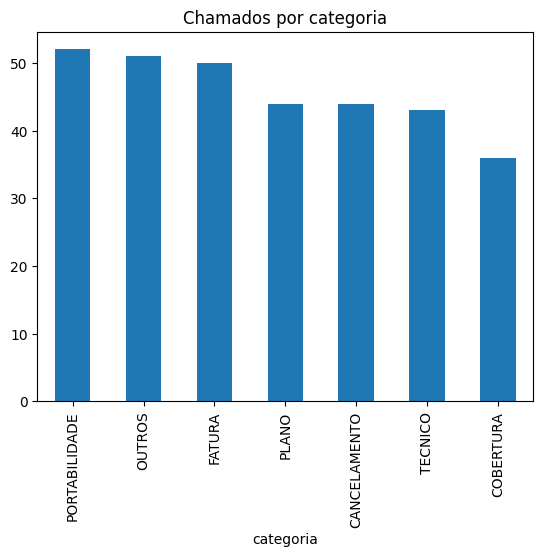

In [20]:
frequencia_categoria = df["categoria"].value_counts()
print(frequencia_categoria)

frequencia_categoria.plot(
    kind="bar",
    title="Chamados por categoria"
)

canal
LOJA FISICA    96
APP            80
CHAT           75
TELEFONE       69
Name: count, dtype: int64


<Axes: title={'center': 'Chamados por canal'}, xlabel='canal'>

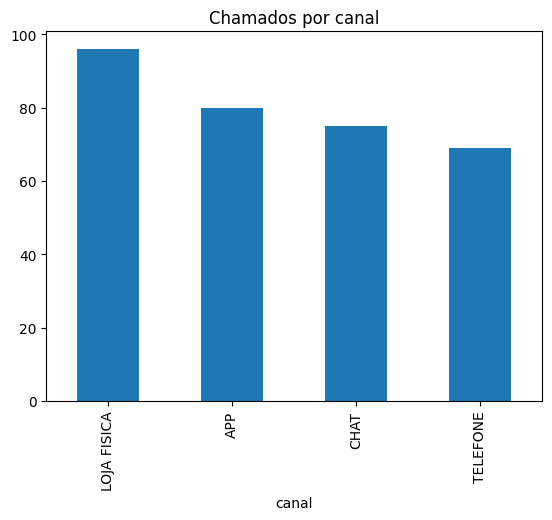

In [21]:
frequencia_canal = df["canal"].value_counts()

print(frequencia_canal)

frequencia_canal.plot(
    kind="bar",
    title="Chamados por canal"
)

In [22]:
print(df["duracao_minutos"].describe())

count    307.000000
mean      18.241042
std        9.218864
min        2.000000
25%       10.000000
50%       18.000000
75%       25.500000
max       35.000000
Name: duracao_minutos, dtype: float64


In [23]:
duracao_categoria = (
    df.groupby("categoria")["duracao_minutos"]
    .mean()
    .sort_values(ascending=False)
)

print(duracao_categoria)

categoria
TECNICO          18.775000
FATURA           18.770833
OUTROS           18.560000
COBERTURA        18.314286
PORTABILIDADE    17.880000
PLANO            17.857143
CANCELAMENTO     17.500000
Name: duracao_minutos, dtype: float64


resolvido_primeiro_contato      False      True 
categoria                                       
CANCELAMENTO                34.090909  65.909091
COBERTURA                   50.000000  50.000000
FATURA                      28.000000  72.000000
OUTROS                      29.411765  70.588235
PLANO                       31.818182  68.181818
PORTABILIDADE               30.769231  69.230769
TECNICO                     41.860465  58.139535


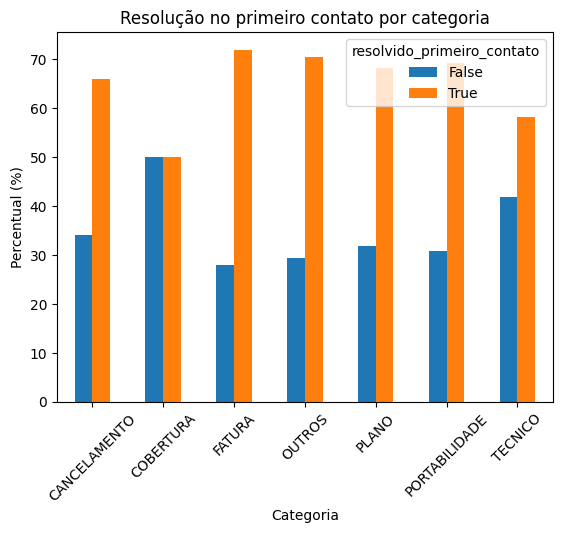

In [24]:
resolucao = pd.crosstab(
    df["categoria"],
    df["resolvido_primeiro_contato"],
    normalize="index"
) * 100

print(resolucao)

resolucao.plot(kind="bar")

plt.title("Resolução no primeiro contato por categoria")
plt.xlabel("Categoria")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=45)
plt.show()

encaminhado_humano      False      True 
categoria                               
CANCELAMENTO        70.454545  29.545455
COBERTURA           55.555556  44.444444
FATURA              82.000000  18.000000
OUTROS              78.431373  21.568627
PLANO               75.000000  25.000000
PORTABILIDADE       73.076923  26.923077
TECNICO             67.441860  32.558140


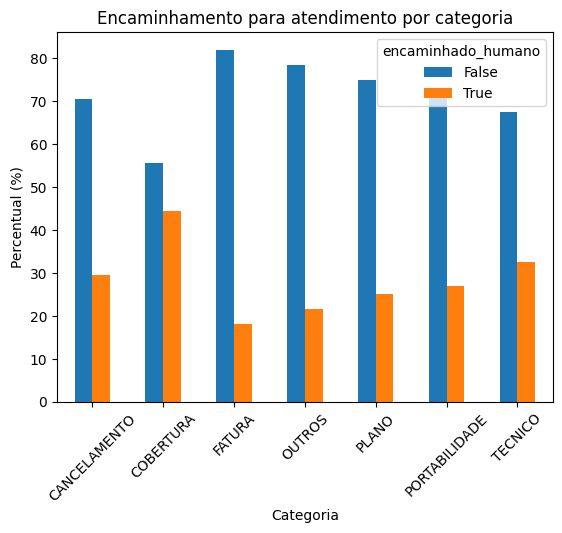

In [25]:
encaminhamento = pd.crosstab(
    df["categoria"],
    df["encaminhado_humano"],
    normalize="index"
) * 100
print(encaminhamento)

encaminhamento.plot(kind="bar")

plt.title("Encaminhamento para atendimento por categoria")
plt.xlabel("Categoria")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=45)
plt.show()

subcategoria
Cancelamento por insatisfação            90.91
Status de portabilidade                  81.25
Solicitação de fatura detalhada          81.25
Valor divergente                         80.00
Segunda via                              80.00
Contestação de valor                     80.00
Cancelamento de complemento              72.73
Elogio                                   69.23
Dúvida sobre franquia                    68.75
Dúvida sobre prazo de portabilidade      68.42
Cobrança indevida                        66.67
Área sem cobertura 4G/5G                 66.67
Troca de plano                           66.67
Erro de configuração de APN              66.67
Sugestão                                 64.29
Adição de pacote de dados                62.50
Dúvida geral                             62.50
Dúvida sobre desconto                    61.54
Aparelho não conecta                     60.00
Chip não funciona                        60.00
Lentidão na internet                     60.00


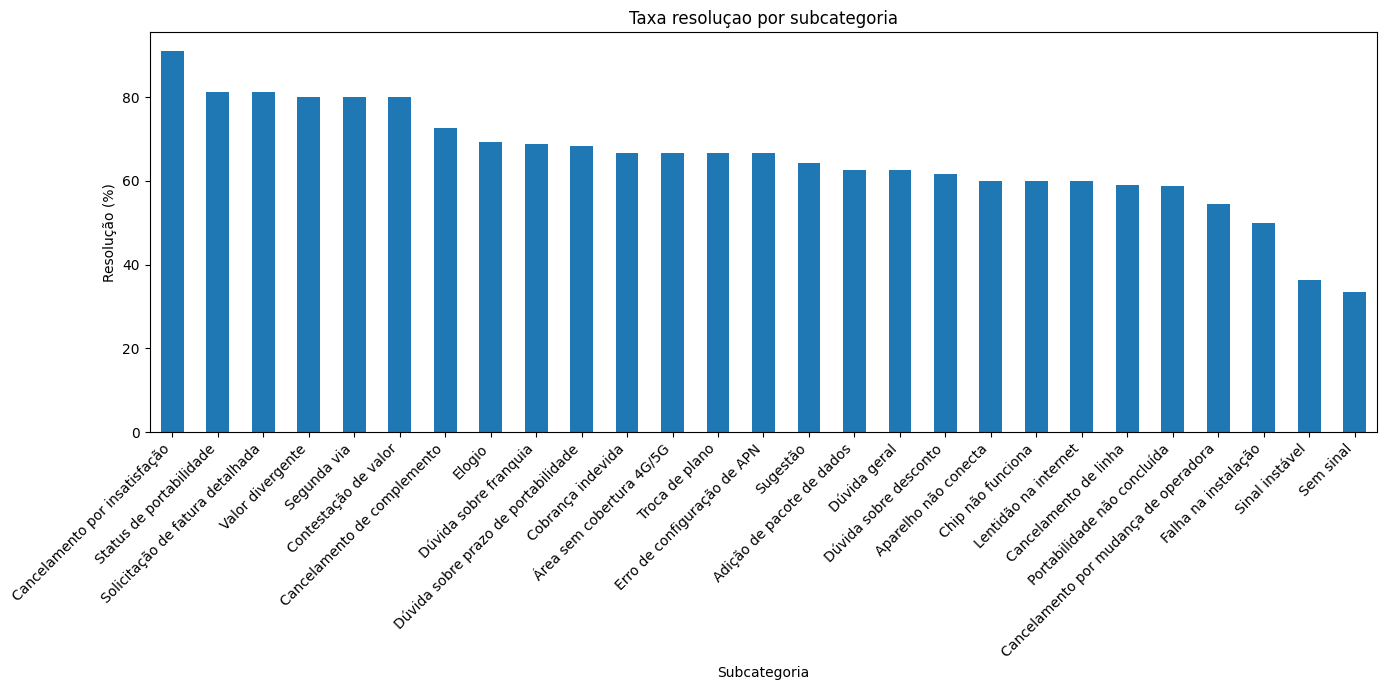

In [26]:
resolucao_sub = pd.crosstab(
    df["subcategoria"],
    df["resolvido_primeiro_contato"],
    normalize="index"
) * 100

resolvidos = (
    resolucao_sub[True]
    .sort_values(ascending=False)
)

print(resolvidos.round(2))

plt.figure(figsize=(14, 7))

resolvidos.plot(kind="bar")

plt.title("Taxa resoluçao por subcategoria")
plt.xlabel("Subcategoria")
plt.ylabel("Resolução (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

subcategoria
Sem sinal                                66.67
Sinal instável                           63.64
Falha na instalação                      50.00
Cancelamento por mudança de operadora    45.45
Cancelamento de linha                    36.36
Portabilidade não concluída              35.29
Erro de configuração de APN              33.33
Dúvida sobre desconto                    30.77
Lentidão na internet                     30.00
Cancelamento de complemento              27.27
Dúvida sobre prazo de portabilidade      26.32
Cobrança indevida                        25.00
Dúvida geral                             25.00
Adição de pacote de dados                25.00
Dúvida sobre franquia                    25.00
Elogio                                   23.08
Área sem cobertura 4G/5G                 22.22
Troca de plano                           22.22
Sugestão                                 21.43
Valor divergente                         20.00
Aparelho não conecta                     20.00


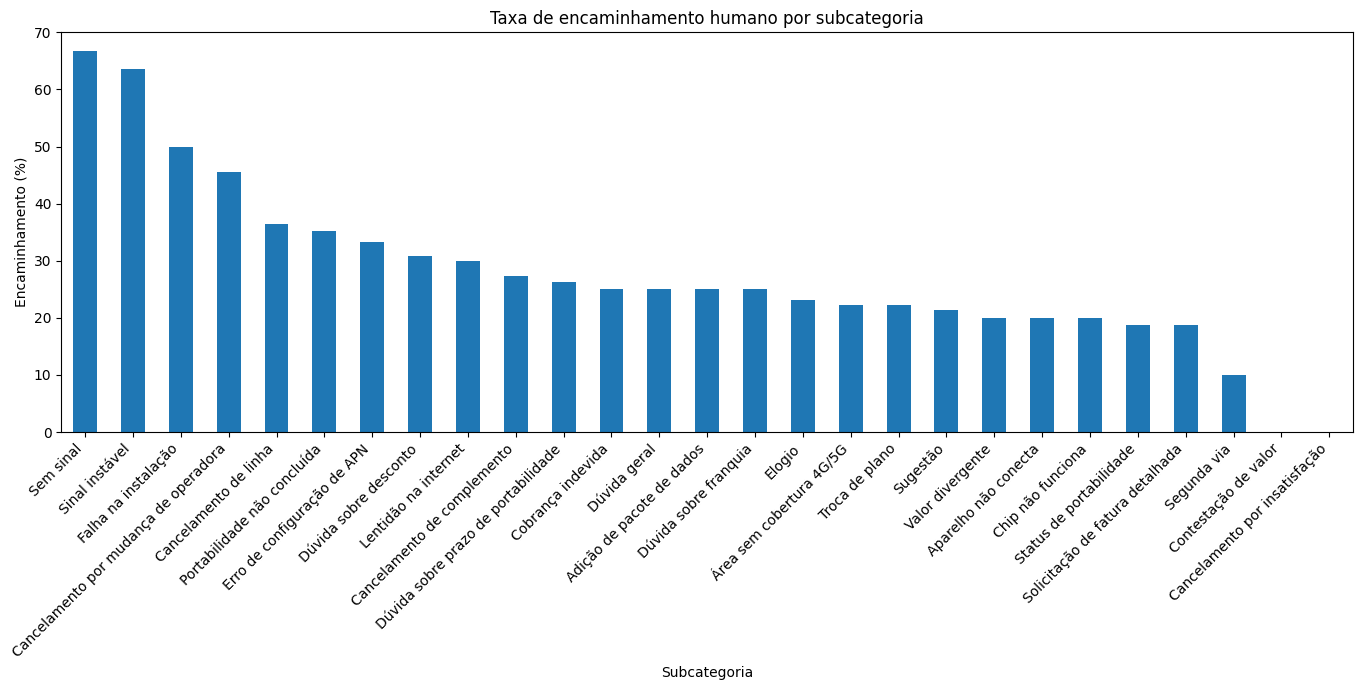

In [27]:
encaminhamento_sub = pd.crosstab(
    df["subcategoria"],
    df["encaminhado_humano"],
    normalize="index"
) * 100

encaminhados = (
    encaminhamento_sub[True]
    .sort_values(ascending=False)
)

print(encaminhados.round(2))

plt.figure(figsize=(14, 7))

encaminhados.plot(kind="bar")

plt.title("Taxa de encaminhamento humano por subcategoria")
plt.xlabel("Subcategoria")
plt.ylabel("Encaminhamento (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

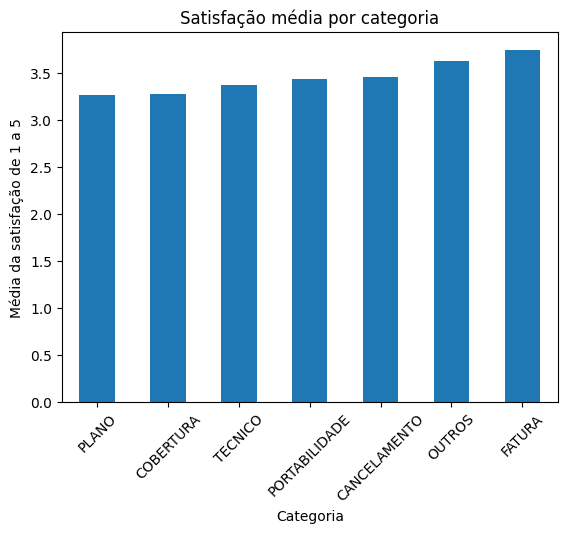

categoria
PLANO            3.264706
COBERTURA        3.275862
TECNICO          3.368421
PORTABILIDADE    3.431818
CANCELAMENTO     3.450000
OUTROS           3.619048
FATURA           3.743590
Name: satisfacao_1_a_5, dtype: float64


In [28]:
satisfacao_media = (
    df.groupby("categoria")["satisfacao_1_a_5"]
    .mean()
    .sort_values()
)

satisfacao_media.plot(kind="bar")

plt.title("Satisfação média por categoria")
plt.xlabel("Categoria")
plt.ylabel("Média da satisfação de 1 a 5")
plt.xticks(rotation=45)
plt.show()

print(satisfacao_media)

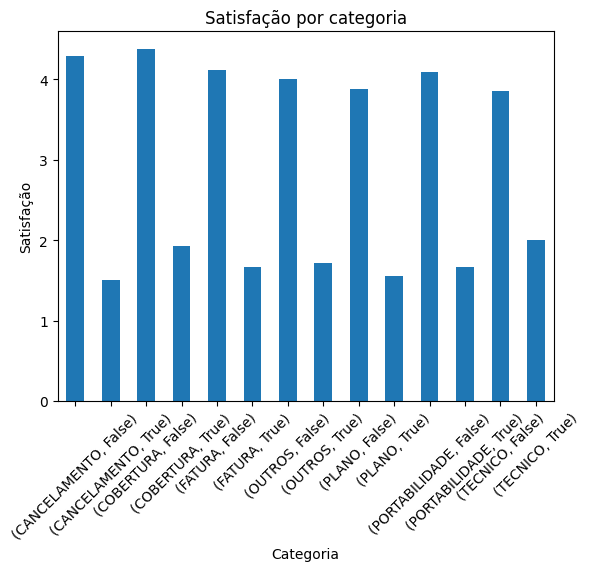

categoria      encaminhado_humano
CANCELAMENTO   False                 4.285714
               True                  1.500000
COBERTURA      False                 4.375000
               True                  1.923077
FATURA         False                 4.121212
               True                  1.666667
OUTROS         False                 4.000000
               True                  1.714286
PLANO          False                 3.880000
               True                  1.555556
PORTABILIDADE  False                 4.093750
               True                  1.666667
TECNICO        False                 3.857143
               True                  2.000000
Name: satisfacao_1_a_5, dtype: float64


In [29]:
satisfacao_encaminhamento = (
    df.groupby(["categoria", "encaminhado_humano"])
      ["satisfacao_1_a_5"]
      .mean()
)

satisfacao_encaminhamento.plot(kind="bar")

plt.title("Satisfação por categoria")
plt.xlabel("Categoria")
plt.ylabel("Satisfação")
plt.xticks(rotation=45)
plt.show()

print(satisfacao_encaminhamento)

In [30]:
satisfacao_resolucao = (
    df.groupby(["categoria", "resolvido_primeiro_contato"])
      ["satisfacao_1_a_5"]
      .mean()
)

print(satisfacao_resolucao)

categoria      resolvido_primeiro_contato
CANCELAMENTO   False                         1.615385
               True                          4.333333
COBERTURA      False                         1.923077
               True                          4.375000
FATURA         False                         1.900000
               True                          4.379310
OUTROS         False                         1.700000
               True                          4.218750
PLANO          False                         1.666667
               True                          4.136364
PORTABILIDADE  False                         1.714286
               True                          4.233333
TECNICO        False                         2.071429
               True                          4.125000
Name: satisfacao_1_a_5, dtype: float64


In [31]:
df["insatisfeito"] = df["satisfacao_1_a_5"].apply(
    lambda x: True if pd.notna(x) and x <= 2 else (False if pd.notna(x) and x > 2 else pd.NA)
)

In [32]:
analise_categoria = df.groupby("categoria").agg(
    chamados=("chamado_id", "count"),
    satisfacao_media=("satisfacao_1_a_5", "mean"),
    taxa_insatisfacao=("insatisfeito", "mean"),
    taxa_resolucao=("resolvido_primeiro_contato", "mean"),
    taxa_encaminhamento=("encaminhado_humano", "mean")
)

analise_categoria["taxa_insatisfacao"] *= 100
analise_categoria["taxa_resolucao"] *= 100
analise_categoria["taxa_encaminhamento"] *= 100

print(analise_categoria.round(2))

               chamados  satisfacao_media taxa_insatisfacao  taxa_resolucao  \
categoria                                                                     
CANCELAMENTO         44              3.45              30.0           65.91   
COBERTURA            36              3.28         34.482759           50.00   
FATURA               50              3.74         20.512821           72.00   
OUTROS               51              3.62         21.428571           70.59   
PLANO                44              3.26         32.352941           68.18   
PORTABILIDADE        52              3.43              25.0           69.23   
TECNICO              43              3.37         26.315789           58.14   

               taxa_encaminhamento  
categoria                           
CANCELAMENTO                 29.55  
COBERTURA                    44.44  
FATURA                       18.00  
OUTROS                       21.57  
PLANO                        25.00  
PORTABILIDADE                

In [33]:
analise_categoria.columns = [
    "Chamados",
    "Satisfação média",
    "Insatisfação (%)",
    "Resolução 1º contato (%)",
    "Encaminhamento humano (%)"
]

analise_categoria.round(2)

,Chamados,Satisfação média,Insatisfação (%),Resolução 1º contato (%),Encaminhamento humano (%)
categoria,,,,,
CANCELAMENTO,44,3.45,30.0,65.91,29.55
COBERTURA,36,3.28,34.482759,50.00,44.44
FATURA,50,3.74,20.512821,72.00,18.00
OUTROS,51,3.62,21.428571,70.59,21.57
PLANO,44,3.26,32.352941,68.18,25.00
PORTABILIDADE,52,3.43,25.0,69.23,26.92
TECNICO,43,3.37,26.315789,58.14,32.56


In [34]:
# =============================================================================
# Exportar política de escalonamento baseada em dados
# =============================================================================
# Esta célula gera o artefato consumido por src/agent/escalation_policy.py.

import json
from datetime import datetime, timezone

LIMIAR_TAXA_ENCAMINHAMENTO_PCT = 50.0  # subcategorias com taxa >= este valor escalam por padrão

analise_subcategoria = df.groupby("subcategoria").agg(
    chamados=("chamado_id", "count"),
    satisfacao_media=("satisfacao_1_a_5", "mean"),
    taxa_insatisfacao=("insatisfeito", "mean"),
    taxa_resolucao=("resolvido_primeiro_contato", "mean"),
    taxa_encaminhamento=("encaminhado_humano", "mean"),
)

analise_subcategoria["taxa_insatisfacao"] *= 100
analise_subcategoria["taxa_resolucao"] *= 100
analise_subcategoria["taxa_encaminhamento"] *= 100


def _safe_round(valor, casas=2):
    return None if pd.isna(valor) else round(float(valor), casas)


politica_escalonamento = {
    "gerado_em": datetime.now(timezone.utc).isoformat(),
    "fonte_dados": "data/raw/log_chamados/log_chamados_sintetico.csv",
    "limiar_taxa_encaminhamento_pct": LIMIAR_TAXA_ENCAMINHAMENTO_PCT,
    "subcategorias": {
        str(subcategoria).strip().lower(): {
            "rotulo_original": subcategoria,
            "chamados": int(row["chamados"]),
            "satisfacao_media": _safe_round(row["satisfacao_media"]),
            "taxa_insatisfacao_pct": _safe_round(row["taxa_insatisfacao"]),
            "taxa_resolucao_pct": _safe_round(row["taxa_resolucao"]),
            "taxa_encaminhamento_pct": _safe_round(row["taxa_encaminhamento"]),
            "escalar_por_padrao": bool(
                not pd.isna(row["taxa_encaminhamento"])
                and row["taxa_encaminhamento"] >= LIMIAR_TAXA_ENCAMINHAMENTO_PCT
            ),
        }
        for subcategoria, row in analise_subcategoria.iterrows()
    },
}

output_path = BASE_DIR / "data" / "processed" / "log_chamados" / "politica_escalonamento.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(politica_escalonamento, f, ensure_ascii=False, indent=2)

n_escalam = sum(v["escalar_por_padrao"] for v in politica_escalonamento["subcategorias"].values())
print(f"Política exportada para {output_path}")
print(f"{n_escalam}/{len(politica_escalonamento['subcategorias'])} subcategorias escalam por padrão (limiar={LIMIAR_TAXA_ENCAMINHAMENTO_PCT}%)")

Política exportada para /home/brayan/concierge-conectaltel/data/processed/log_chamados/politica_escalonamento.json
3/27 subcategorias escalam por padrão (limiar=50.0%)
